### Your name:

<pre> JU ZHANG </pre>

### Collaborators:

<pre> None </pre>


In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
# to make this notebook's output stable across runs
np.random.seed(123)

# To plot pretty figures
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12


##### Note -- the code is running on TensorFlow 2 with Python 3.12.7

### TensorFlow

Q1. When is a variable initialized? When is it destroyed?

##### Answer
A TensorFlow 1.x-style `Variable` is created when the graph is built, but its value is initialized only when its initializer runs, usually with `sess.run(tf.global_variables_initializer())` or by restoring it from a checkpoint. It is destroyed when the session/graph that owns it is closed or discarded. In TensorFlow 2/Keras eager mode, variables are initialized immediately when the `tf.Variable` or layer weight is created, and Python garbage collection destroys them when nothing references them anymore.

Q2. What is the difference between a placeholder and a variable?

##### Answer
A placeholder is an input slot in a TensorFlow 1.x graph: it has a dtype/shape, but no stored value, so the caller must provide data with `feed_dict` each time the graph runs. A variable stores mutable model state such as weights and biases. Variables are trained, saved, restored, and updated by optimizers; placeholders are just temporary inputs for one run.

Q3. How many times does reverse-mode autodiff need to traverse the graph in order to compute the gradients of the cost function with regards to 10 variables? What about forward-mode autodiff? And symbolic differentiation?

##### Answer
Reverse-mode autodiff needs one forward pass plus one backward traversal to compute all 10 gradients of one scalar cost function. Forward-mode autodiff would need one pass per variable, so 10 graph traversals for 10 variables. Symbolic differentiation can create one derivative graph per variable, so it also grows roughly with the number of variables and can produce very large expression graphs.

Q4. Implement Logistic Regression with Mini-batch Gradient Descent using TensorFlow. Train it and evaluate it on the moons dataset (introduced in Chapter 5). Try adding all the bells and whistles:

- Define the graph within a logistic_regression() function that can be reused easily.

- Save checkpoints using a Saver at regular intervals during training, and save the final model at the end of training.

- Restore the last checkpoint upon startup if training was interrupted.

- Define the graph using name scopes so the graph looks good in TensorBoard.

- Add summaries to visualize the learning curves in TensorBoard.

- Try tweaking some hyperparameters such as the learning rate or the mini-batch size and look at the shape of the learning curve.

**Explanation:** This solution uses TensorFlow 2 with Keras. The moons dataset is loaded with `sklearn.datasets.make_moons`, expanded with polynomial features, and split with `sklearn.model_selection.train_test_split` so the train/test split is shuffled and stratified. The logistic regression model is a single Keras `Dense(1, activation='sigmoid')` layer. Mini-batch gradient descent is used through `model.fit(..., batch_size=50)` with the SGD optimizer: Keras processes 50 training examples at a time and applies one gradient update after each mini-batch. Keras callbacks handle TensorBoard learning-curve logging and checkpoint saving/restoring. The callback uses `write_graph=False` because TensorBoard's Graph tab can fail on some Keras/TensorFlow 2 event files, while the Scalars tab remains the useful view for this homework.


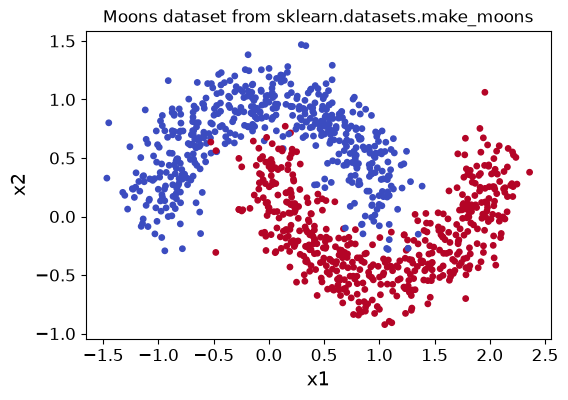

In [2]:
from pathlib import Path

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# Keep TensorFlow's random initialization reproducible across notebook runs.
tf.random.set_seed(123)

# Load the moons dataset using scikit-learn. This is the dataset
# introduced earlier in the course: two interleaving half-circles with noise.
# X_moons has the two original coordinates [x1, x2]; y_moons has class labels
# 0 and 1. Reshape y to a column vector because TensorFlow losses below expect
# shape (n_samples, 1), not (n_samples,).
X_moons, y_moons = make_moons(n_samples=1000, noise=0.18, random_state=123)
X_moons = X_moons.astype(np.float32)
y_moons = y_moons.reshape(-1, 1).astype(np.float32)

# Basic logistic regression is linear in its inputs, so it would draw a
# straight decision boundary in the original x1/x2 plane. Adding polynomial
# features lets the same linear classifier represent a curved boundary.
def add_moon_features(X):
    x1 = X[:, 0:1]
    x2 = X[:, 1:2]
    return np.c_[x1, x2, x1 ** 2, x2 ** 2, x1 * x2].astype(np.float32)

X_moons_plus = add_moon_features(X_moons)

# Use scikit-learn's train_test_split instead of slicing by position. It
# shuffles before splitting and stratify=y_moons keeps the class balance about
# the same in both sets. These variable names are reused in Q5.
X_train, X_test, y_train, y_test = train_test_split(
    X_moons_plus,
    y_moons,
    test_size=0.2,
    random_state=123,
    shuffle=True,
    stratify=y_moons,
)

plt.figure(figsize=(6, 4))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons.ravel(), cmap='coolwarm', s=15)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Moons dataset from sklearn.datasets.make_moons')
plt.show()


In [3]:
# Keras version of logistic regression. A single Dense layer with one sigmoid
# output is exactly logistic regression over the engineered moon features.
def logistic_regression(n_inputs, learning_rate=0.08):
    model = tf.keras.Sequential(
        [
            tf.keras.layers.Input(shape=(n_inputs,), name='features'),
            tf.keras.layers.Dense(
                1,
                activation='sigmoid',
                name='class_probability',
            ),
        ],
        name='logistic_regression_keras',
    )

    # SGD is the gradient descent optimizer. Combined with batch_size in
    # model.fit(), this becomes mini-batch gradient descent.
    model.compile(
        optimizer=tf.keras.optimizers.SGD(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy'],
    )
    return model

class EveryNEpochsCheckpoint(tf.keras.callbacks.Callback):
    """Save a reusable Keras checkpoint every N epochs."""

    def __init__(self, checkpoint_dir, every=100):
        super().__init__()
        self.checkpoint_dir = Path(checkpoint_dir)
        self.every = every
        self.latest_path = self.checkpoint_dir / 'latest.keras'
        self.checkpoint_dir.mkdir(parents=True, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        # epoch is zero-based, so epoch + 1 is the human-readable epoch count.
        epoch_number = epoch + 1
        if epoch_number % self.every == 0:
            # Save both a numbered checkpoint and a stable latest.keras file.
            # latest.keras is what the next run restores if training stopped.
            numbered_path = self.checkpoint_dir / f'epoch_{epoch_number:04d}.keras'
            self.model.save(numbered_path)
            self.model.save(self.latest_path)

tf.keras.backend.clear_session()

logdir = Path('tf_logs/logistic_regression_keras_sklearn_split_scalars_tf2')
checkpoint_dir = Path('checkpoints/logistic_regression_keras_sklearn_split_tf2')
latest_checkpoint = checkpoint_dir / 'latest.keras'

# Restore the latest saved Keras model if it exists; otherwise create a fresh
# logistic regression model. This replaces the old TensorFlow 1 Saver pattern.
if latest_checkpoint.exists():
    logistic_model = tf.keras.models.load_model(latest_checkpoint)
    print('Restored', latest_checkpoint)
else:
    logistic_model = logistic_regression(X_train.shape[1], learning_rate=0.08)

# Hyperparameters. batch_size is the key setting that makes training
# mini-batch gradient descent rather than full-batch gradient descent.
n_epochs = 800
batch_size = 50
checkpoint_every = 100

callbacks = [
    # Writes the Keras loss/accuracy curves to TensorBoard.
    # write_graph=False avoids TensorBoard Graph-tab parsing errors that can
    # happen with some TF2/Keras event files; use the Scalars tab for curves.
    tf.keras.callbacks.TensorBoard(
        log_dir=str(logdir),
        histogram_freq=0,
        write_graph=False,
    ),

    # Saves the model at regular epoch intervals, similar in spirit to Saver.
    EveryNEpochsCheckpoint(checkpoint_dir, every=checkpoint_every),
]

# Keras performs mini-batch gradient descent here:
# - It shuffles the training data at the start of each epoch by default.
# - It splits X_train/y_train into mini-batches of 50 examples.
# - For each mini-batch, it computes the binary cross-entropy loss, computes
#   gradients, and SGD applies one weight update.
history = logistic_model.fit(
    X_train,
    y_train,
    epochs=n_epochs,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    verbose=0,
)

# Save the final model after training finishes.
final_checkpoint = checkpoint_dir / 'final_model.keras'
logistic_model.save(final_checkpoint)

final_loss, final_accuracy = logistic_model.evaluate(X_test, y_test, verbose=0)

print('Saved final checkpoint:', final_checkpoint)
print(f'Test accuracy: {final_accuracy:.3f}')
print(f'Test loss: {final_loss:.3f}')



Saved final checkpoint: checkpoints\logistic_regression_keras_sklearn_split_tf2\final_model.keras
Test accuracy: 0.855
Test loss: 0.283


Q5. Similar to the linear regression implementation in class, write a lasso regression implementation. Use the same dataset, and choose a value for the penalty $\alpha$:

Using a Saver at regular intervals during training, and save the final model at the end of training.

Restore the last checkpoint upon startup if training was interrupted.

Define the graph using name scopes so the graph looks good in TensorBoard.

Add summaries to visualize the learning curves in TensorBoard.

Try tweaking some hyperparameters such as the learning rate or the mini-batch size and look at the shape of the learning curve.

**Explanation:** Lasso regression is ordinary linear regression plus an L1 penalty on the weights. This TensorFlow 2 version reuses the engineered moons features from Q4 and treats the class label as a numeric 0/1 regression target. Training is written with `tf.GradientTape`, checkpoints are handled with `tf.train.CheckpointManager`, and optional TensorBoard summaries show the MSE, total objective, and learned weights over time.


In [4]:
# Reuse the moons features from Q4. Lasso is a regression model, so here the
# class label is treated as a numeric target: 0.0 for class 0 and 1.0 for
# class 1. The model will predict continuous values, not probabilities.
X_reg_train, y_reg_train = X_train, y_train
X_reg_test, y_reg_test = X_test, y_test

# This is the same mini-batch idea as Q4, kept as a separate helper so the
# regression training loop reads clearly on its own.
def random_regression_batch(X, y, batch_size):
    idx = np.random.randint(len(X), size=batch_size)
    return X[idx], y[idx]

print('Training examples:', X_reg_train.shape[0])
print(X_reg_train)
print('Features:', X_reg_train.shape[1])
print('Target range:', y_reg_train.min(), 'to', y_reg_train.max())


Training examples: 800
[[-0.14813232  0.7874153   0.02194319  0.6200229  -0.11664166]
 [ 1.4309078  -0.13216898  2.0474973   0.01746864 -0.18912163]
 [ 0.75373536  0.2907242   0.568117    0.08452056  0.2191291 ]
 ...
 [ 0.1943257   0.22579104  0.03776248  0.05098159  0.043877  ]
 [ 2.158892    0.42323327  4.6608143   0.1791264   0.9137149 ]
 [-0.10808053  0.83484876  0.0116814   0.6969724  -0.0902309 ]]
Features: 5
Target range: 0.0 to 1.0


In [5]:
class LassoRegressionTF2(tf.Module):
    """Linear regression model used for the Lasso objective."""

    def __init__(self, n_inputs, name='lasso_regression'):
        super().__init__(name=name)

        # theta contains one weight per engineered feature; bias is the
        # intercept. Both are trainable variables saved by Checkpoint.
        with self.name_scope:
            self.theta = tf.Variable(
                tf.random.normal([n_inputs, 1], stddev=0.1), name='theta'
            )
            self.bias = tf.Variable(0.0, name='bias')

    def __call__(self, X):
        # Linear prediction: y_pred = X @ theta + bias.
        with tf.name_scope('model'):
            return tf.matmul(X, self.theta) + self.bias

# Create the model and optimizer together so the function is reusable with
# different feature counts, learning rates, or alpha values.
def lasso_regression(n_inputs, learning_rate=0.03, alpha=0.05):
    with tf.name_scope('lasso_regression'):
        model = LassoRegressionTF2(n_inputs)
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    return model, optimizer, alpha

def lasso_losses(model, X, y, alpha):
    with tf.name_scope('loss'):
        y_pred = model(X)

        # MSE measures how close the continuous predictions are to the 0/1
        # targets. This is the ordinary linear regression part.
        mse = tf.reduce_mean(tf.square(y_pred - y))

        # The L1 penalty is the Lasso part. It pushes unnecessary weights
        # toward zero, which can make the model simpler. Bias is not penalized.
        l1_penalty = alpha * tf.reduce_sum(tf.abs(model.theta))
        total_loss = mse + l1_penalty
        return y_pred, mse, l1_penalty, total_loss

@tf.function
def train_lasso_step(model, optimizer, X_batch, y_batch, alpha):
    # The optimizer minimizes the full objective: MSE + alpha * L1 norm.
    with tf.name_scope('train'):
        with tf.GradientTape() as tape:
            _, _, _, total_loss = lasso_losses(model, X_batch, y_batch, alpha)
        gradients = tape.gradient(total_loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))
        return total_loss

tf.keras.backend.clear_session()
lasso_model, lasso_optimizer, alpha = lasso_regression(
    X_reg_train.shape[1], learning_rate=0.03, alpha=0.05
)

# Store TF2 lasso files separately from the old TF1 or NumPy-generated dataset checkpoints.
logdir = Path('tf_logs/lasso_regression_sklearn_split_tf2')
checkpoint_dir = Path('checkpoints/lasso_regression_sklearn_split_tf2')
checkpoint_dir.mkdir(parents=True, exist_ok=True)
checkpoint = tf.train.Checkpoint(model=lasso_model, optimizer=lasso_optimizer)
manager = tf.train.CheckpointManager(checkpoint, str(checkpoint_dir), max_to_keep=3)

# Restore the latest TF2 checkpoint if this cell was interrupted previously.
if manager.latest_checkpoint:
    checkpoint.restore(manager.latest_checkpoint).expect_partial()
    print('Restored', manager.latest_checkpoint)

# Hyperparameters for the lasso training run. Try changing alpha or the
# learning rate and watch how the objective curve changes.
n_epochs = 1000
batch_size = 64
checkpoint_every = 100
summary_every = 50

train_writer = tf.summary.create_file_writer(str(logdir))
summary_enabled = True
for epoch in range(n_epochs):
    X_batch, y_batch = random_regression_batch(X_reg_train, y_reg_train, batch_size)
    train_lasso_step(lasso_model, lasso_optimizer, X_batch, y_batch, alpha)

    if epoch % summary_every == 0:
        _, train_mse, train_l1, train_loss = lasso_losses(
            lasso_model, X_reg_train, y_reg_train, alpha
        )

        # Log scalar curves and the weight distribution for TensorBoard. If
        # TensorBoard is not installed, skip logging but keep training.
        if summary_enabled:
            try:
                with train_writer.as_default():
                    tf.summary.scalar('mse', train_mse, step=epoch)
                    tf.summary.scalar('l1_penalty', train_l1, step=epoch)
                    tf.summary.scalar('total_loss', train_loss, step=epoch)
                    tf.summary.histogram('theta', lasso_model.theta, step=epoch)
            except Exception as exc:
                summary_enabled = False
                print('TensorBoard summaries skipped:', exc)

    if epoch % checkpoint_every == 0:
        manager.save(checkpoint_number=epoch)

# Evaluate on the held-out test data and inspect the learned parameters.
_, test_mse, test_l1_penalty, test_loss = lasso_losses(
    lasso_model, X_reg_test, y_reg_test, alpha
)
learned_theta = lasso_model.theta.numpy()
learned_bias = lasso_model.bias.numpy()
final_checkpoint = manager.save(checkpoint_number=n_epochs)
train_writer.close()

print('Saved final checkpoint:', final_checkpoint)
print(f'Test MSE: {test_mse.numpy():.3f}')
print(f'Test L1 penalty: {test_l1_penalty.numpy():.3f}')
print(f'Test objective with L1 penalty: {test_loss.numpy():.3f}')
print('Learned theta:', learned_theta.ravel())
print('Learned bias:', learned_bias)


Saved final checkpoint: checkpoints\lasso_regression_sklearn_split_tf2\ckpt-1000
Test MSE: 0.100
Test L1 penalty: 0.032
Test objective with L1 penalty: 0.132
Learned theta: [ 1.5877759e-01 -4.7970396e-01  6.7101797e-04  1.0377553e-05
 -1.9535646e-03]
Learned bias: 0.52281845


In [6]:
# To inspect the learning curves after running the training cells, start TensorBoard
# from a terminal in this project folder:
#
# tensorboard --logdir tf_logs
